# Compute tensions using tensiometer between:
- $\Lambda CDM$ model
- $w_0 w_a CDM$ model
- Quintessence (Exponential Potential)

(likelihood of ACT, PLANCK and DESI DR2)

In [1]:
# Show plots inline, and load main getdist plot module and samples class
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 1
# import libraries:
import sys, os
#os.environ['TF_USE_LEGACY_KERAS'] = '1'
sys.path.insert(0,os.path.realpath(os.path.join(os.getcwd(),'../..')))
from getdist import plots
#from getdist.gaussian_mixtures import from_confidence_to_sigma
import getdist
getdist.chains.print_load_details = False

# import the tensiometer tools that we need:
import tensiometer
from tensiometer import utilities
from tensiometer import mcmc_tension

### Loading samples

In [2]:
# Loading samples
#lcdm:
chain_lcdm = os.path.join('/home/andrewcats/tesi_magistrale/lcdm/act_planck_desidr2', 'act_planck_desidr2')
samples_lcdm = getdist.mcsamples.loadMCSamples(file_root=chain_lcdm, settings={'ignore_rows':0.3})
#print('Parameters: ', samples.paramNames.names)
param_names_lcdm = [param.name for param in samples_lcdm.paramNames.names]
print(param_names_lcdm)

#w0wacdm:
chain_w0wa = os.path.join('/home/andrewcats/tesi_magistrale/w0wacdm/act_planck_desidr2', 'act_planck_desidr2')
samples_w0wa = getdist.mcsamples.loadMCSamples(file_root=chain_w0wa, settings={'ignore_rows':0.3})
#print('Parameters: ', samples.paramNames.names)
param_names_w0wa = [param.name for param in samples_w0wa.paramNames.names]
print(param_names_w0wa)

#EFT_exp:
chain_exp = os.path.join('/home/andrewcats/tesi_magistrale/eftcamb/eftcamb_exponential/lcdm_eft_exp/act_planck_desidr2', '1_EXP_lcdm_act_planck_desidr2')
samples_exp = getdist.mcsamples.loadMCSamples(file_root=chain_exp, settings={'ignore_rows':0.3})
#print('Parameters: ', samples.paramNames.names)
param_names_exp = [param.name for param in samples_exp.paramNames.names]
print(param_names_exp)


['H0', 'logA', 'ns', 'ombh2', 'omch2', 'tau', 'A_act', 'P_act', 'A', 'As', 'DHBBN', 'YHe', 'Y_p', 'age', 'clamp', 'omega_de', 'omegam', 'omegamh2', 'rdrag', 's8h5', 'S8_optimal', 's8omegamp25', 's8omegamp5', 'sigma8', 'thetastar', 'zrei', 'A_planck', 'chi2__BAO', 'chi2__CMB', 'chi2', 'chi2__planck_2018_lowl.TT', 'chi2__planck_2018_lowl.EE_sroll2', 'chi2__act_dr6_cmbonly.PlanckActCut', 'chi2__act_dr6_cmbonly', 'chi2__bao.desi_dr2.desi_bao_all']
['H0', 'logA', 'ns', 'ombh2', 'omch2', 'tau', 'w', 'wa', 'A_act', 'P_act', 'A', 'As', 'DHBBN', 'YHe', 'Y_p', 'age', 'clamp', 'omega_de', 'omegam', 'omegamh2', 'rdrag', 's8h5', 'S8_optimal', 's8omegamp25', 's8omegamp5', 'sigma8', 'thetastar', 'zrei', 'A_planck', 'chi2__BAO', 'chi2__CMB', 'chi2', 'chi2__planck_2018_lowl.TT', 'chi2__planck_2018_lowl.EE_sroll2', 'chi2__act_dr6_cmbonly.PlanckActCut', 'chi2__act_dr6_cmbonly', 'chi2__bao.desi_dr2.desi_bao_all']
['H0', 'logA', 'ns', 'ombh2', 'omch2', 'tau', 'A_act', 'P_act', 'EFT_lambda', 'A', 'As', 'DHB

In [3]:
# the difference chain:
diff_chain_w0wa = mcmc_tension.parameter_diff_chain(samples_w0wa, samples_lcdm, boost=4)
diff_chain_exp = mcmc_tension.parameter_diff_chain(samples_exp, samples_lcdm, boost=4)

In [4]:
#param_names = diff_chain.getParamNames().getRunningNames()
#g = plots.get_subplot_plotter()
#g.triangle_plot([diff_chain], params=param_names, filled=True, markers={_p:0 for _p in param_names})

### Between $w_0 w_a CDM$ and $\Lambda CDM$

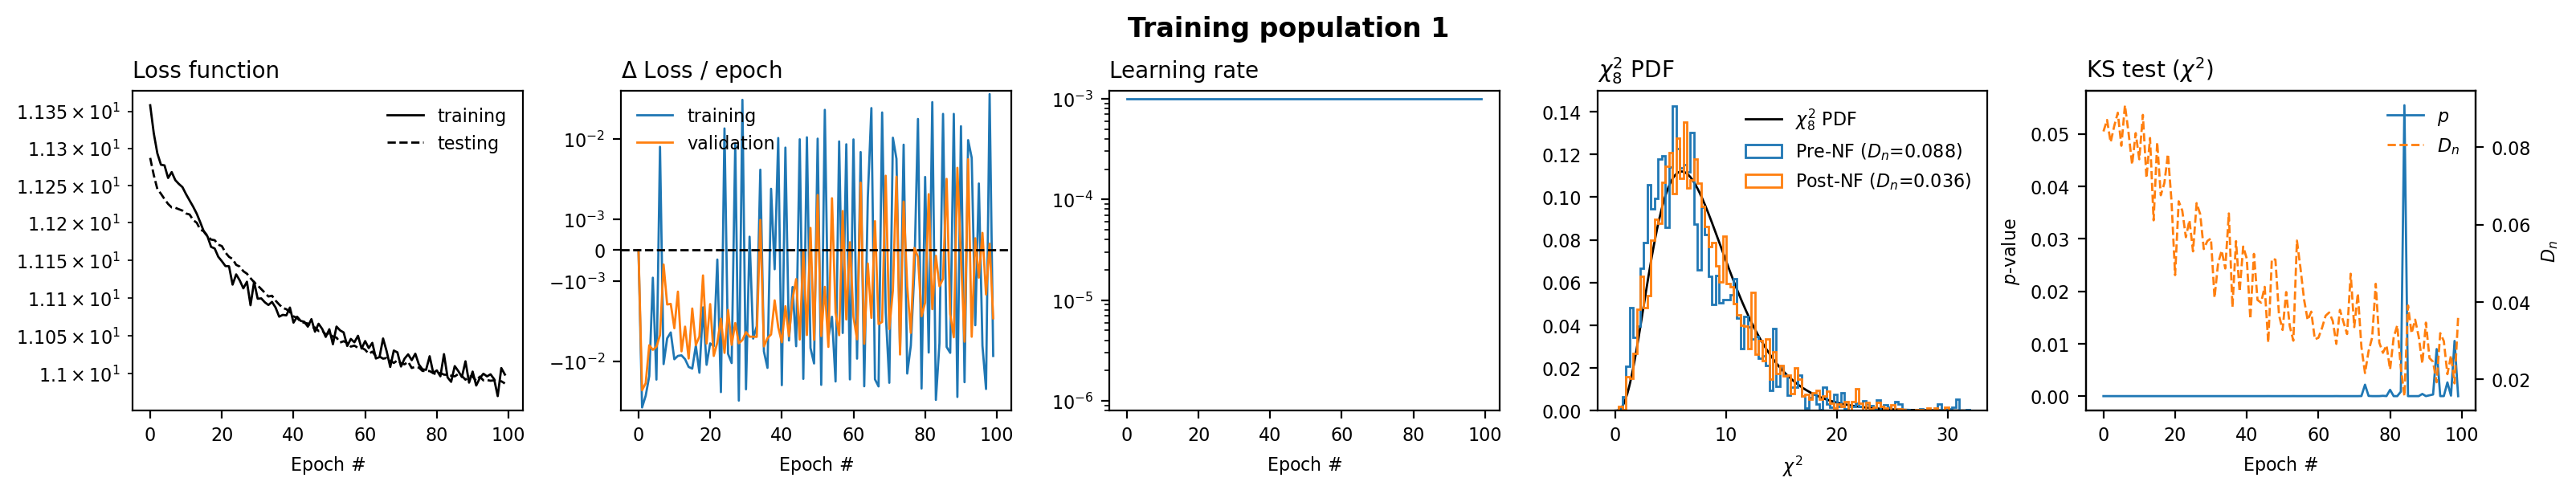

20/20 - 2s - loss: 10.9986 - val_loss: 10.9870 - lr: 0.0010 - 2s/epoch - 93ms/step
* Population optimizer:
    - best model is number 1
    - best loss function is 11.0
    - best validation loss function is 10.99
    - population losses [10.99]


In [5]:
# the helper function passes all keyword arguments downstream so we can easily set manually all options
kwargs = {
          'feedback': 2,  # verbosity level
          'pop_size': 1,  # controls the number of flows that are trained. The best one is then selected. Since time to solution scales linearly with pop_size, it is a good idea to set it to 1 for a first run. 
        }

# call the helper function:
results_w0wa, diff_flow_w0wa = tensiometer.mcmc_tension.flow_parameter_shift(diff_chain_w0wa,   # parameter difference chain
                                      cache_dir=None,  # directory where the trained flow is saved, to save time next time
                                      root_name='sprob',  # name of the cached flow (usefull to have several in the same folder)
                                      **kwargs
                                      )

# unpack results:
shift_P_w0wa, shift_hi_w0wa, shift_low_w0wa = results_w0wa


In [6]:
print(f'Shift probability considering all parameters:\n',
      f'   P = {shift_P:.5f} +{shift_hi-shift_P:.5f} -{shift_P-shift_low:.5f}')
# turn the result to effective number of sigmas:
print(f'    n_sigma = {utilities.from_confidence_to_sigma(shift_P):.3f}',
      f'+{utilities.from_confidence_to_sigma(shift_hi)-utilities.from_confidence_to_sigma(shift_P):.3f}',
      f'-{utilities.from_confidence_to_sigma(shift_P)-utilities.from_confidence_to_sigma(shift_low):.3f}')

NameError: name 'shift_P' is not defined

### Between Quintessence (exponential potential) and $\Lambda CDM$

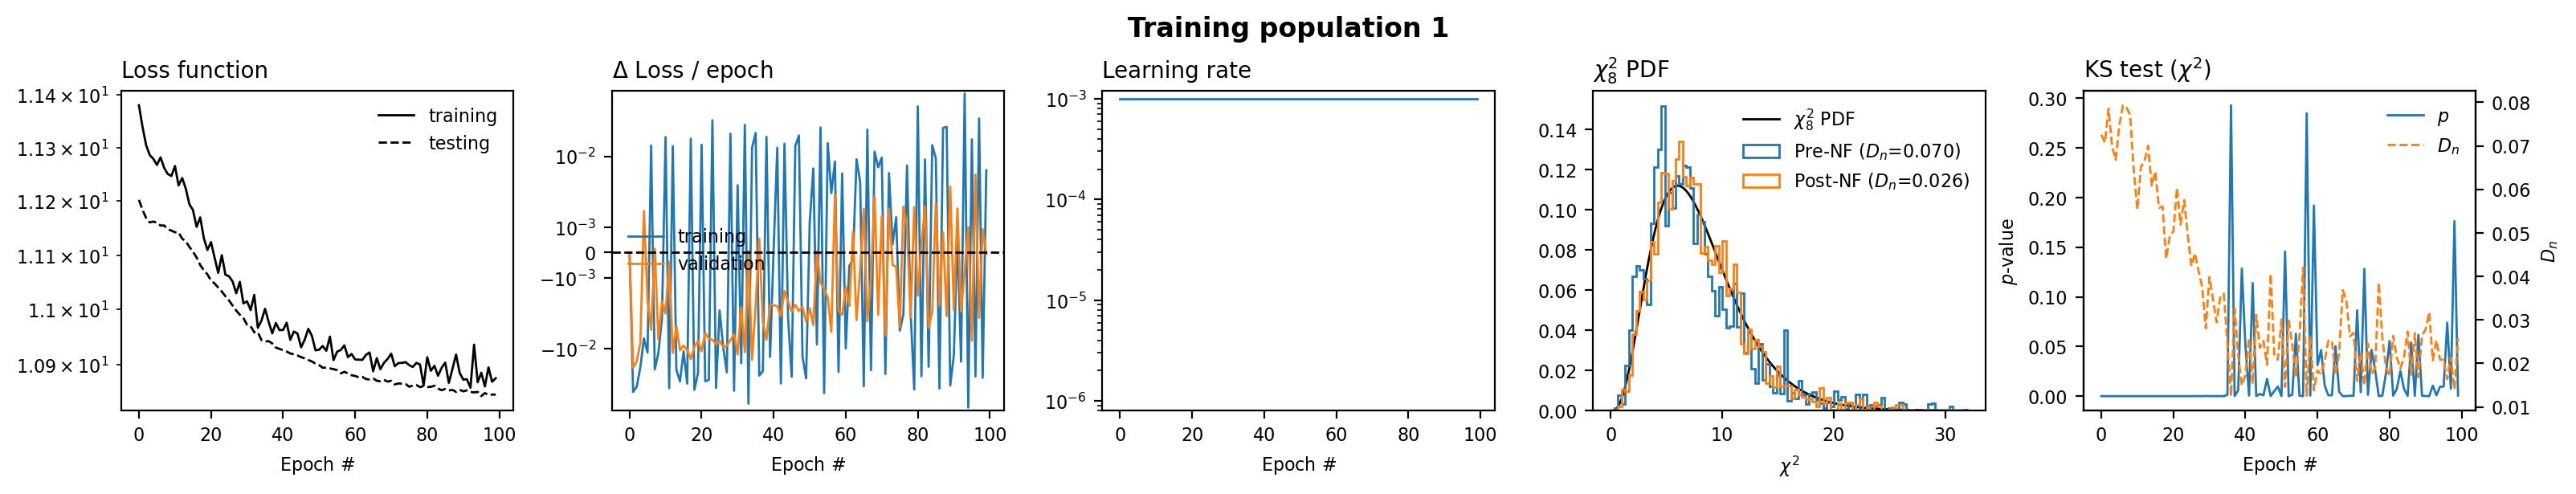

20/20 - 2s - loss: 10.8754 - val_loss: 10.8458 - lr: 0.0010 - 2s/epoch - 97ms/step
* Population optimizer:
    - best model is number 1
    - best loss function is 10.88
    - best validation loss function is 10.85
    - population losses [10.85]


In [7]:
# call the helper function:
results_exp, diff_flow_exp = tensiometer.mcmc_tension.flow_parameter_shift(diff_chain_exp,   # parameter difference chain
                                      cache_dir=None,  # directory where the trained flow is saved, to save time next time
                                      root_name='sprob',  # name of the cached flow (usefull to have several in the same folder)
                                      **kwargs
                                      )

# unpack results:
shift_P_exp, shift_hi_exp, shift_low_exp = results_exp
